In [43]:
root_dir = ".."
tool_path = "../../detecty-thingy/dist/sql-antipattern-detector"

In [44]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [45]:
ground_truth_df = pd.read_csv(f"{root_dir}/datasets/test-set.csv")
ground_truth_df = ground_truth_df.drop(columns=["Line from", "Line to", "Comment"])
ground_truth_df = ground_truth_df.drop_duplicates()
ground_truth_df.sort_values(by=["Antipattern", "Project", "File"], ascending=True, ignore_index=True)

,Project,Antipattern,File
0,therepanic/trustwin-casino-project,31 Flavors,game-crash-service/src/main/java/eu/panic/gamecrashservice/generatedClasses/tables/UsersTable.java
1,therepanic/trustwin-casino-project,31 Flavors,game-dice-service/src/main/java/eu/panic/gamediceservice/generatedClasses/tables/UsersTable.java
2,therepanic/trustwin-casino-project,31 Flavors,game-jackpot-service/src/main/java/eu/panic/gamejackpotservice/generatedClasses/tables/UsersTable.java
3,therepanic/trustwin-casino-project,31 Flavors,game-miner-service/src/main/java/eu/panic/gameminerservice/generatedClasses/tables/MessagesTable.java
4,therepanic/trustwin-casino-project,31 Flavors,game-miner-service/src/main/java/eu/panic/gameminerservice/generatedClasses/tables/ReplenishmentsTable.java
5,therepanic/trustwin-casino-project,31 Flavors,game-miner-service/src/main/java/eu/panic/gameminerservice/generatedClasses/tables/UsersTable.java
6,therepanic/trustwin-casino-project,31 Flavors,game-miner-service/src/main/java/eu/panic/gameminerservice/generatedClasses/tables/WithdrawalsTable.java
7,therepanic/trustwin-casino-project,31 Flavors,game-overgo-service/src/main/java/eu/panic/gameovergoservice/generatedClasses/tables/UsersTable.java
8,therepanic/trustwin-casino-project,31 Flavors,game-tower-service/src/main/java/eu/panic/gametowerservice/generatedClasses/tables/MessagesTable.java
9,therepanic/trustwin-casino-project,31 Flavors,game-tower-service/src/main/java/eu/panic/gametowerservice/generatedClasses/tables/ReplenishmentsTable.java


In [46]:
projects = ground_truth_df["Project"].unique().tolist()
projects

['Andrey582/NotificationBot',
 'balazskrizsan/stackjudge_aws_java',
 'BuchnevDmitry/LinkTracker',
 'corradomio/java_projects',
 'Efler/telegram-scrapper-bot',
 'gonzo1138/jOOQinSpring-basics',
 'jOOQ/jOOQ-mcve',
 'kaeru61/chat_app',
 'killbill/killbill-stripe-plugin',
 'lightningdevkit/vss-server',
 'linux-china/jooq-demo',
 'NurtilekMamashakirov/Bot-Link-Tracker',
 'revensif/Tinkoff_Course2024',
 'rodano/rodano',
 'shileishmily/spring-boot-jooq-demo',
 'Subtelny/DGCraft',
 'therepanic/trustwin-casino-project',
 'xnelo/filearch',
 'yangjinguang/i-share-server',
 'ydeng11/Minance']

In [47]:
def get_project_dir(project: str):
    return f"{root_dir}/repositories/{project.replace("/", "_")}"

In [48]:
import os
import time

start_time = time.perf_counter()

project_result_dfs = [
    pd.read_csv(os.popen(
        f"{tool_path} {get_project_dir(project)} --format csv --model openrouter:anthropic/claude-opus-4.5 --temperature 0.0 --thinking-effort none --retries 1000 --mode classification"
    ))
    for project in projects
]

end_time = time.perf_counter()
total_runtime = end_time - start_time

print("\n--- Analysis Summary ---")
print(f"Total Runtime:      {total_runtime:.2f} seconds")


--- Analysis Summary ---
Total Runtime:      295.11 seconds


In [49]:
results_df = pd.concat(project_result_dfs, ignore_index=True)
results_df

,Project,Antipattern,File
0,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatRepository.java
1,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java
2,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java
3,Andrey582_NotificationBot,Beware of the Unknown,scrapper/src/main/java/edu/java/database/jooq/tables/ChatToLink.java
4,Andrey582_NotificationBot,ID Required,scrapper/src/main/java/edu/java/database/jooq/tables/Link.java
5,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/updater/JooqLinkUpdater.java
6,balazskrizsan_stackjudge_aws_java,Beware of the Unknown,src/main/java/com/kbalazsworks/stackjudge_aws/db/tables/RemoteFiles.java
7,balazskrizsan_stackjudge_aws_java,Implicit Columns,src/main/java/com/kbalazsworks/stackjudge_aws/s3/repositories/RemoteFileRepository.java
8,BuchnevDmitry_LinkTracker,Implicit Columns,scrapper/src/main/java/edu/java/scrapper/domain/jooq/impl/JooqChatRepository.java
9,BuchnevDmitry_LinkTracker,Implicit Columns,scrapper/src/main/java/edu/java/scrapper/domain/jooq/impl/JooqLinkRepository.java


In [50]:
ground_truth_df['Project'] = ground_truth_df['Project'].str.replace('/', '_')
results_df['Antipattern'] = results_df['Antipattern'].str.replace('\'', '’')

In [51]:
import pandas as pd

# --- 1. Data Preparation ---

# Ensure strict types and clean whitespace
for df in [ground_truth_df, results_df]:
    df['Project'] = df['Project'].astype(str).str.strip()
    df['Antipattern'] = df['Antipattern'].astype(str).str.strip()
    df['File'] = df['File'].astype(str).str.strip()

# --- 2. Metric Calculation ---

all_antipatterns = sorted(
    set(ground_truth_df['Antipattern']).union(set(results_df['Antipattern']))
)
metric_rows = []

for ap in all_antipatterns:
    # Filter by Antipattern
    gt_subset = ground_truth_df[ground_truth_df['Antipattern'] == ap]
    pred_subset = results_df[results_df['Antipattern'] == ap]
    
    # Create sets of (Project, File) tuples for easy matching
    gt_set = set(zip(gt_subset['Project'], gt_subset['File']))
    pred_set = set(zip(pred_subset['Project'], pred_subset['File']))
    
    # Standard Classification Logic:
    # TP: Exists in both GT and Pred
    # FP: Exists in Pred but not in GT
    # FN: Exists in GT but not in Pred
    
    tp = len(gt_set.intersection(pred_set))
    total_gt = len(gt_set)
    total_pred = len(pred_set)
    
    # Calculate Rates
    precision = tp / total_pred if total_pred > 0 else 0.0
    recall = tp / total_gt if total_gt > 0 else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall) 
        if (precision + recall) > 0 
        else 0.0
    )
        
    metric_rows.append({
        "Antipattern": ap,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Support (GT Count)": total_gt,
        "Pred Count": total_pred
    })

# --- 3. Weighted Average and Output ---

metrics_df = pd.DataFrame(metric_rows)
total_support = metrics_df["Support (GT Count)"].sum()

if total_support > 0:
    w_avg_prec = (
        metrics_df["Precision"] * metrics_df["Support (GT Count)"]
    ).sum() / total_support
    w_avg_rec = (
        metrics_df["Recall"] * metrics_df["Support (GT Count)"]
    ).sum() / total_support
    w_avg_f1 = (
        metrics_df["F1-Score"] * metrics_df["Support (GT Count)"]
    ).sum() / total_support
else:
    w_avg_prec, w_avg_rec, w_avg_f1 = 0.0, 0.0, 0.0

# Append Weighted Average Row
weighted_avg_row = pd.DataFrame([{
    "Antipattern": "WEIGHTED AVERAGE",
    "Precision": w_avg_prec,
    "Recall": w_avg_rec,
    "F1-Score": w_avg_f1,
    "Support (GT Count)": total_support,
    "Pred Count": metrics_df["Pred Count"].sum()
}])

metrics_df = pd.concat([metrics_df, weighted_avg_row], ignore_index=True)

# Display results rounded to 4 decimal places
print(metrics_df.round(4).to_string(index=False))

             Antipattern  Precision  Recall  F1-Score  Support (GT Count)  Pred Count
              31 Flavors     1.0000  1.0000    1.0000                  15          15
   Beware of the Unknown     0.3488  0.8824    0.5000                  17          43
             ID Required     0.9500  0.9048    0.9268                 105         100
        Implicit Columns     0.9535  0.9880    0.9704                  83          86
           Keyless Entry     0.4091  1.0000    0.5806                  18          44
Poor Man’s Search Engine     1.0000  0.9091    0.9524                  11          10
         Rounding Errors     1.0000  0.6000    0.7500                  15           9
        WEIGHTED AVERAGE     0.8833  0.9242    0.8846                 264         307


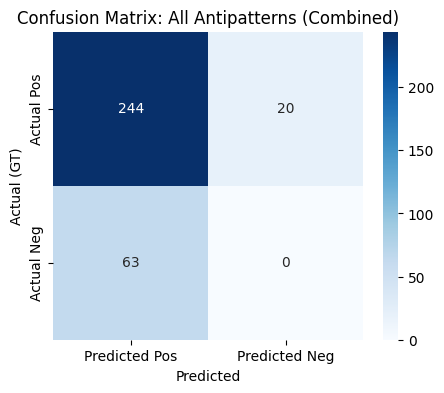

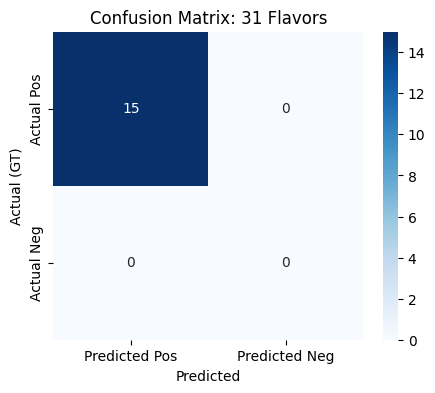

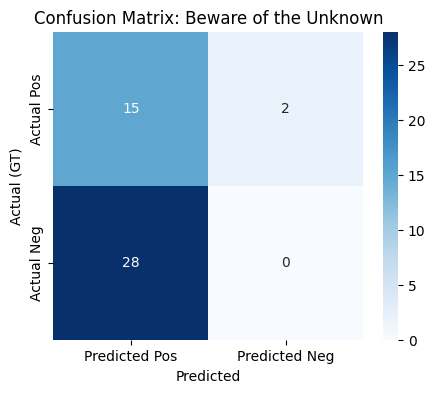

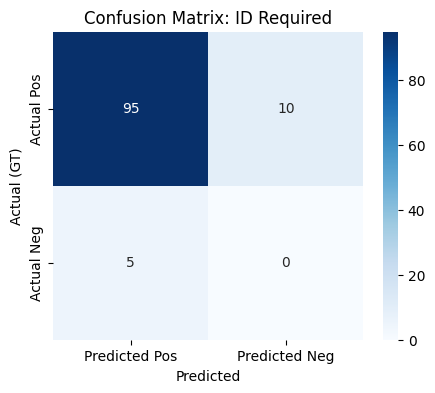

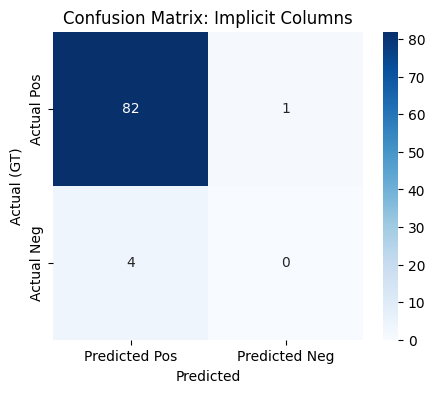

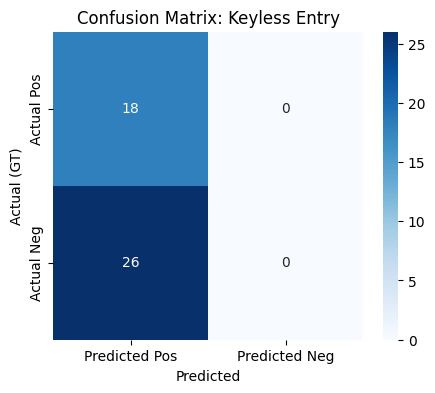

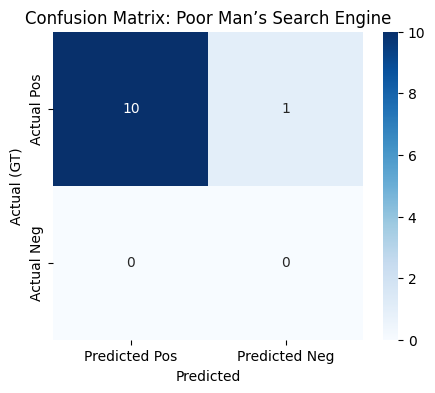

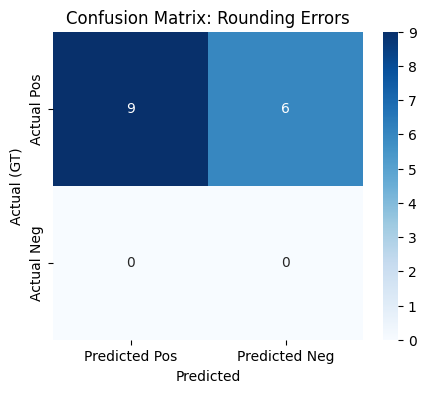

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_ap_confusion_matrix(tp, fp, fn, title):
    """
    Plots a 2x2 confusion matrix with Positive at the top-left.
    TN is marked as N/A or 0 as it's not defined in this detection task.
    """
    # Structure: [[TP, FN], [FP, 0]]
    cm = np.array([[tp, fn], [fp, 0]])
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Pos', 'Predicted Neg'], 
                yticklabels=['Actual Pos', 'Actual Neg'])
    
    plt.ylabel('Actual (GT)')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

# --- Calculate Data for Confusion Matrices ---
ap_stats = {}
global_tp = 0
global_fp = 0
global_fn = 0

# all_antipatterns should be the set created in the previous step
for ap in all_antipatterns:
    # Filter datasets by current antipattern
    gt_subset = ground_truth_df[ground_truth_df['Antipattern'] == ap]
    pred_subset = results_df[results_df['Antipattern'] == ap]
    
    # Create sets of (Project, File)
    gt_set = set(zip(gt_subset['Project'], gt_subset['File']))
    pred_set = set(zip(pred_subset['Project'], pred_subset['File']))
    
    # Calculate stats
    tp = len(gt_set.intersection(pred_set))
    fn = len(gt_set - pred_set)
    fp = len(pred_set - gt_set)
    
    ap_stats[ap] = {'tp': tp, 'fp': fp, 'fn': fn}
    
    # Accumulate for global stats
    global_tp += tp
    global_fp += fp
    global_fn += fn

# --- Rendering ---

# 1. Global Confusion Matrix
plot_ap_confusion_matrix(global_tp, global_fp, global_fn, "All Antipatterns (Combined)")

# 2. Individual Confusion Matrices
for ap, stats in ap_stats.items():
    plot_ap_confusion_matrix(stats['tp'], stats['fp'], stats['fn'], ap)

In [53]:

# --- 1. Efficient Filtering using Merge ---

# We perform a "left join" on the three identifying columns.
# The 'indicator=True' argument adds a column named '_merge' 
# showing if the row exists in 'both', 'left_only', or 'right_only'.
merged = ground_truth_df.merge(
    results_df[['Project', 'Antipattern', 'File']], 
    on=['Project', 'Antipattern', 'File'], 
    how='left', 
    indicator=True
)

# Rows that exist only in the 'left' (Ground Truth) are the missing ones
missing_df = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])

# --- 2. Output ---

print(f"Found {len(missing_df)} instances in Ground Truth not matched in Results.")

# Display the missing instances
missing_df

Found 20 instances in Ground Truth not matched in Results.


,Project,Antipattern,File
0,Andrey582_NotificationBot,ID Required,scrapper/src/main/java/edu/java/database/jooq/tables/Chat.java
5,balazskrizsan_stackjudge_aws_java,ID Required,src/main/java/com/kbalazsworks/stackjudge_aws/db/tables/RemoteFiles.java
18,Efler_telegram-scrapper-bot,Beware of the Unknown,scrapper/src/main/java/edu/eflerrr/scrapper/service/jooq/JooqLinkService.java
23,gonzo1138_jOOQinSpring-basics,Implicit Columns,src/main/java/org/anisation/jooqbasics/HelloController.java
28,jOOQ_jOOQ-mcve,ID Required,jOOQ-mcve-java-mysql/src/main/java/org/jooq/mcve/java/mysql/tables/Test.java
64,rodano_rodano,ID Required,backend/src/main/java/ch/rodano/core/model/jooq/tables/Chart.java
66,rodano_rodano,ID Required,backend/src/main/java/ch/rodano/core/model/jooq/tables/DatasetAudit.java
68,rodano_rodano,ID Required,backend/src/main/java/ch/rodano/core/model/jooq/tables/EventAudit.java
69,rodano_rodano,ID Required,backend/src/main/java/ch/rodano/core/model/jooq/tables/File.java
75,rodano_rodano,ID Required,backend/src/main/java/ch/rodano/core/model/jooq/tables/RobotAudit.java


In [54]:
# --- 1. Efficient Filtering using Merge ---

# We perform a "left join" starting from results_df.
# indicator=True adds a '_merge' column.
merged_ghosts = results_df.merge(
    ground_truth_df[['Project', 'Antipattern', 'File']], 
    on=['Project', 'Antipattern', 'File'], 
    how='left', 
    indicator=True
)

# Rows that exist 'left_only' are results that did not match any Ground Truth entry
ghosts_df = merged_ghosts[merged_ghosts['_merge'] == 'left_only'].drop(columns=['_merge'])

# --- 2. Output ---

print(f"Found {len(ghosts_df)} instances in Results that are not in Ground Truth.")

# Display the "ghost" (False Positive) instances
ghosts_df

Found 63 instances in Results that are not in Ground Truth.


,Project,Antipattern,File
3,Andrey582_NotificationBot,Beware of the Unknown,scrapper/src/main/java/edu/java/database/jooq/tables/ChatToLink.java
5,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/updater/JooqLinkUpdater.java
14,corradomio_java_projects,Beware of the Unknown,check_odb4j/src/main/java/test/generated/tables/Author.java
22,gonzo1138_jOOQinSpring-basics,Implicit Columns,src/main/java/org/anisation/jooqbasics/DbAccess.java
37,jOOQ_jOOQ-mcve,Beware of the Unknown,jOOQ-mcve-java-sqlserver/src/main/java/org/jooq/mcve/java/sqlserver/tables/Test.java
43,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/ChatRooms.java
45,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/ChatRoomUsers.java
47,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/Messages.java
49,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/Users.java
50,killbill_killbill-stripe-plugin,ID Required,src/main/java/org/killbill/billing/plugin/stripe/dao/gen/tables/StripePaymentMethods.java


In [ ]:
Date	Slug	Usage	BYOK Usage	API Key
2026-04-13 12:41:00	anthropic/claude-opus-4.5	0.543715	0	Unknown
2026-04-13 12:40:00	anthropic/claude-opus-4.5	2.79253	0	Unknown
2026-04-13 12:39:00	anthropic/claude-opus-4.5	4.6748	0	Unknown
2026-04-13 12:38:00	anthropic/claude-opus-4.5	1.11793	0	Unknown
2026-04-13 12:37:00	anthropic/claude-opus-4.5	2.70281	0	Unknown
2026-04-13 12:36:00	anthropic/claude-opus-4.5	0.307215	0	Unknown
